# Olist E-Commerce Strategic Customer Segmentation Analysis
### Data Platform Analytics & Behavioral Value Pipeline
---
**Project Objective:** Process raw transactional data, engineer behavioral features using the RFM (Recency, Frequency, Monetary) framework, and generate distribution matrices for downstream executive BI dashboarding.

In [1]:
import pandas as pd 
import numpy as np 

## 1. Data Ingestion & Relational Integrity Preservation
> *Loading core transactional profiles. Unused files (such as geolocation data) are safely preserved in the raw datasets directory to protect original relational integrity for potential future project expansions.*

In [2]:
orders=pd.read_csv('datasets/olist_orders_dataset.csv')
payments=pd.read_csv('datasets/olist_order_payments_dataset.csv')
customers=pd.read_csv('datasets/olist_customers_dataset.csv')

## 2. Transactional Consolidation & Data Scrubbing
> *Handling multi-line item payment distributions, standardizing datetime fields, and resolving row duplication to establish a reliable base database grain for accurate metrics.*

In [3]:
merged1_df=pd.merge(orders,customers,on='customer_id',how='inner')

In [4]:
merged1_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [5]:
merged2_df=pd.merge(merged1_df,payments,on='order_id',how='inner')
merged2_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12


In [6]:
#merged orders,customers and payments tables 

final_merged_df=merged2_df[['customer_unique_id','order_id','order_status','order_purchase_timestamp','payment_value']]
final_merged_df.head()

,customer_unique_id,order_id,order_status,order_purchase_timestamp,payment_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,18.12
1,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2.00
2,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,18.59
3,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,141.46
4,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,179.12


In [7]:
final_merged_df=final_merged_df[final_merged_df['order_status']=='delivered']
final_merged_df.head()

,customer_unique_id,order_id,order_status,order_purchase_timestamp,payment_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,18.12
1,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2.00
2,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,18.59
3,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,141.46
4,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,179.12


In [8]:
#removing mutiple duplicate records which are created due to payment using mutiple modes for same orderabs
clean_df=final_merged_df.groupby(['order_id','customer_unique_id','order_purchase_timestamp']).agg({'payment_value':'sum'}).reset_index()
clean_df.head()

,order_id,customer_unique_id,order_purchase_timestamp,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,72.19
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,259.83
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,216.87
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,218.04


In [9]:
clean_df['order_purchase_timestamp']=pd.to_datetime(clean_df['order_purchase_timestamp'])

dataset_max_date=clean_df['order_purchase_timestamp'].max()
assumed_today_date=dataset_max_date+pd.Timedelta(days=1)
print(f'The date on which analysis taking place is one day after our last order was placed and it is {assumed_today_date}')

The date on which analysis taking place is one day after our last order was placed and it is 2018-08-30 15:00:37


## 3. Behavioral Feature Engineering (RFM Metric Computations)
> *Extracting operational value markers across three main customer behaviors: Recency (days since terminal transaction), Frequency (discrete order velocity), and Monetary Value (total gross revenue capture).*

In [10]:
rfm_df=clean_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (assumed_today_date-x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()
rfm_df.columns=['customer_unique_id','Recency','Frequency','Monetary']
print(f'RFM metrics dataframe is created successfully\n')
rfm_df.head()

RFM metrics dataframe is created successfully



,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [11]:
frequency_distribution=rfm_df['Frequency'].value_counts().reset_index()
frequency_distribution

,Frequency,count
0,1,90556
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


In [12]:
def categorize_recency(recency):
    if recency<=90:
        return 'Active (0-3) months'
    elif recency<=180:
        return 'Recent (3-6) months'
    elif recency<=365: 
        return 'Dormant (6-12) months'
    else:
        return 'Lapsed 1+ years'

rfm_df['Recency_category']=rfm_df['Recency'].apply(categorize_recency)

def categorize_frequency(frequency):
    if frequency==1:
        return 'One Time Shopper'
    elif frequency==2:
        return 'Repeat Customer'
    else:
        return 'Elite Loyal User'

rfm_df['Frequency_category']=rfm_df['Frequency'].apply(categorize_frequency)

rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,Recency_category,Frequency_category
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,Recent (3-6) months,One Time Shopper
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,Recent (3-6) months,One Time Shopper
2,0000f46a3911fa3c0805444483337064,537,1,86.22,Lapsed 1+ years,One Time Shopper
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,Dormant (6-12) months,One Time Shopper
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,Dormant (6-12) months,One Time Shopper


In [13]:
monetary_distribution=rfm_df['Monetary'].describe(percentiles=[0.10,0.25,0.50,0.75,0.90,0.95,0.99])
monetary_distribution

count    93357.000000
mean       165.198772
std        226.314579
min          9.590000
10%         40.100000
25%         63.060000
50%        107.780000
75%        182.560000
90%        318.082000
95%        469.622000
99%       1097.063600
max      13664.080000
Name: Monetary, dtype: float64

In [14]:
total_revenue=rfm_df['Monetary'].sum()
VIP_customers=rfm_df[rfm_df['Monetary']>469]
VIP_revenue=VIP_customers['Monetary'].sum()
VIP_count=VIP_customers.shape[0]

VIP_revenue_contribution=(VIP_revenue/total_revenue)*100
VIP_customers_percentage=(VIP_count/rfm_df.shape[0])*100

print(f'VIP contribution in total revenue is {VIP_revenue_contribution:.2f}%')
print(f'VIP customers percentage is {VIP_customers_percentage:.2f}%')

VIP contribution in total revenue is 26.83%
VIP customers percentage is 5.01%


In [15]:
def categorise_monetary(monetary):
    if monetary<=63:
        return 'Low Spender'
    elif monetary<=182: 
        return 'Mid tier Spender'
    elif monetary<=469: 
        return 'Big Spender'
    else: 
        return 'VIP Spender'

rfm_df['Monetary_category']=rfm_df['Monetary'].apply(categorise_monetary)
rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,Recency_category,Frequency_category,Monetary_category
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,Recent (3-6) months,One Time Shopper,Mid tier Spender
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,Recent (3-6) months,One Time Shopper,Low Spender
2,0000f46a3911fa3c0805444483337064,537,1,86.22,Lapsed 1+ years,One Time Shopper,Mid tier Spender
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,Dormant (6-12) months,One Time Shopper,Low Spender
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,Dormant (6-12) months,One Time Shopper,Big Spender


In [16]:
rfm_df=rfm_df.sort_values(by='Monetary',ascending=False).reset_index(drop=True)
rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,Recency_category,Frequency_category,Monetary_category
0,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,Dormant (6-12) months,One Time Shopper,VIP Spender
1,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,Lapsed 1+ years,Repeat Customer,VIP Spender
2,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,Active (0-3) months,One Time Shopper,VIP Spender
3,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,Lapsed 1+ years,One Time Shopper,VIP Spender
4,459bef486812aa25204be022145caa62,35,1,6922.21,Active (0-3) months,One Time Shopper,VIP Spender


## 4. Algorithmic Segment Allocation
> *Applying conditional routing boundaries to divide the customer base into distinct, actionable cohorts (Champions, New Shoppers, VIP at Risk, Slipping, Hibernating).*

In [17]:
def assign_segment(r,f,m):
    if r == 'Active (0-3) months' and f in ['Repeat Customer','Elite Loyal User'] and m in ['VIP Spender','Big Spender']: 
        return 'Champion'
    elif r in ['Dormant (6-12) months','Lapsed 1+ years'] and m in ['VIP Spender','Big Spender']: 
        return 'VIP at Risk'
    elif r == 'Active (0-3) months' and f == 'One Time Shopper': 
        return 'New Shopper'
    elif r in ['Recent (3-6) months','Dormant (6-12) months'] :
        return 'Slipping'
    else:
        return 'Hibernating'

rfm_df['Customer_segment']=rfm_df.apply(lambda row : assign_segment(row['Recency_category'],row['Frequency_category'],row['Monetary_category']),axis=1)
rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,Recency_category,Frequency_category,Monetary_category,Customer_segment
0,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,Dormant (6-12) months,One Time Shopper,VIP Spender,VIP at Risk
1,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,Lapsed 1+ years,Repeat Customer,VIP Spender,VIP at Risk
2,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,Active (0-3) months,One Time Shopper,VIP Spender,New Shopper
3,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,Lapsed 1+ years,One Time Shopper,VIP Spender,VIP at Risk
4,459bef486812aa25204be022145caa62,35,1,6922.21,Active (0-3) months,One Time Shopper,VIP Spender,New Shopper


In [18]:
segment_counts=rfm_df['Customer_segment'].value_counts().reset_index()
segment_counts.columns=['Customer_segment','Total Customers']
segment_counts['Percentage']=(segment_counts['Total Customers']/rfm_df.shape[0])*100
segment_counts.round(2)

,Customer_segment,Total Customers,Percentage
0,Slipping,45585,48.83
1,New Shopper,17845,19.11
2,Hibernating,15957,17.09
3,VIP at Risk,13564,14.53
4,Champion,406,0.43


In [19]:
total_revenue_report=rfm_df.groupby('Customer_segment').agg({
    'customer_unique_id': 'count',
    'Monetary': 'sum'
}).reset_index()
total_revenue_report.columns=['Customer_segment','Total_customers','Total_revenue']
total_platform_revenue=rfm_df['Monetary'].sum()
total_revenue_report['revenue_contribution']=(total_revenue_report['Total_revenue']/total_platform_revenue)*100
total_revenue_report=total_revenue_report.sort_values(by='Total_revenue',ascending=False).reset_index(drop=True)
total_revenue_report

,Customer_segment,Total_customers,Total_revenue,revenue_contribution
0,Slipping,45585,5652451.23,36.650772
1,VIP at Risk,13564,5274922.29,34.202855
2,New Shopper,17845,2916268.51,18.909228
3,Hibernating,15957,1407145.72,9.124002
4,Champion,406,171674.02,1.113143


## 5. Production Delivery Layer (State Exports)
> *Freezing computed dataframes to the 'output/' folder as clean CSV data arrays to completely decouple heavy calculation logic from downstream visualization layers.*

In [20]:
rfm_df.to_csv('output/olist_customer_operational_ledger.csv',index=False)
total_revenue_report.to_csv('output/olist_executive_revenue_matrix.csv',index=False)
segment_counts.to_csv('output/olist_marketing_volume_share.csv',index=False)

## 6. Executive Presentation Layer (Macro Metrics Dashboard)
> *Engineering high-contrast, symmetric distributions to analyze the corporate asymmetries between customer base population scale (Volume) versus financial yield (Value).*

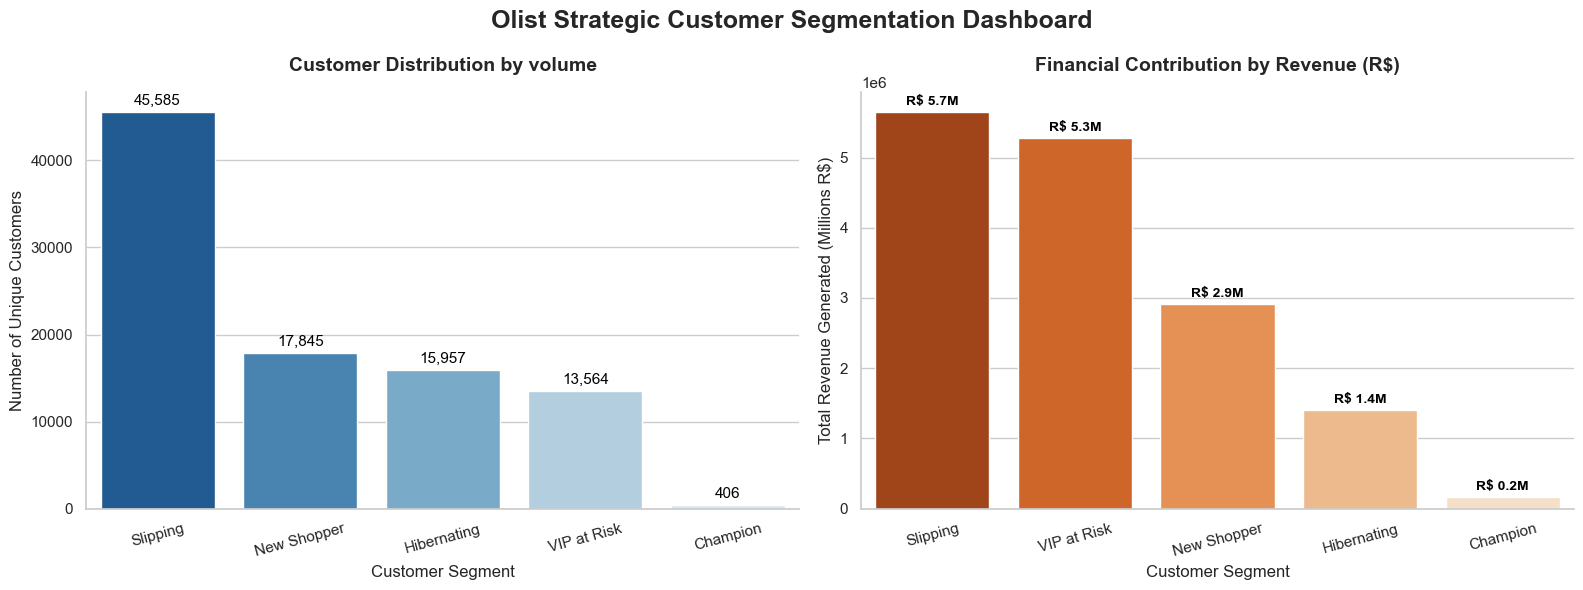

In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style='whitegrid')
fig,ax = plt.subplots(1,2,figsize=(16,6))

sns.barplot(
    data=segment_counts,
    x='Customer_segment',
    y='Total Customers',
    hue='Customer_segment',
    palette='Blues_r', 
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Customer Distribution by volume',fontsize=14,fontweight='bold',pad=15)
ax[0].set_xlabel('Customer Segment',fontsize=12)
ax[0].set_ylabel('Number of Unique Customers',fontsize=12)
ax[0].tick_params(axis='x',rotation=15)

for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}",(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',va='baseline',fontsize=11,color='black',xytext=(0,5),textcoords="offset points")


sns.barplot(
    data=total_revenue_report,
    x='Customer_segment',
    y='Total_revenue', 
    hue='Customer_segment',
    palette='Oranges_r', 
    legend=False,
    ax=ax[1]
)
ax[1].set_title('Financial Contribution by Revenue (R$)', fontsize=14, fontweight='bold', pad=15)
ax[1].set_xlabel('Customer Segment', fontsize=12)
ax[1].set_ylabel('Total Revenue Generated (Millions R$)', fontsize=12)
ax[1].tick_params(axis='x', rotation=15)

for p in ax[1].patches:
    revenue=p.get_height()
    formatted_revenue=f"R$ {revenue/1_000_000:.1f}M"
    ax[1].annotate(formatted_revenue,(p.get_x()+p.get_width()/2.,p.get_height()),ha='center',va='baseline',fontsize=10,fontweight='bold',xytext=(0,5),textcoords='offset  points',color='black')

sns.despine(top=True,right=True)
fig.suptitle('Olist Strategic Customer Segmentation Dashboard',fontsize=18,fontweight='bold')
plt.tight_layout()
plt.savefig('output/customer_segmentation_performance.png',dpi=300,bbox_inches='tight')
plt.show()

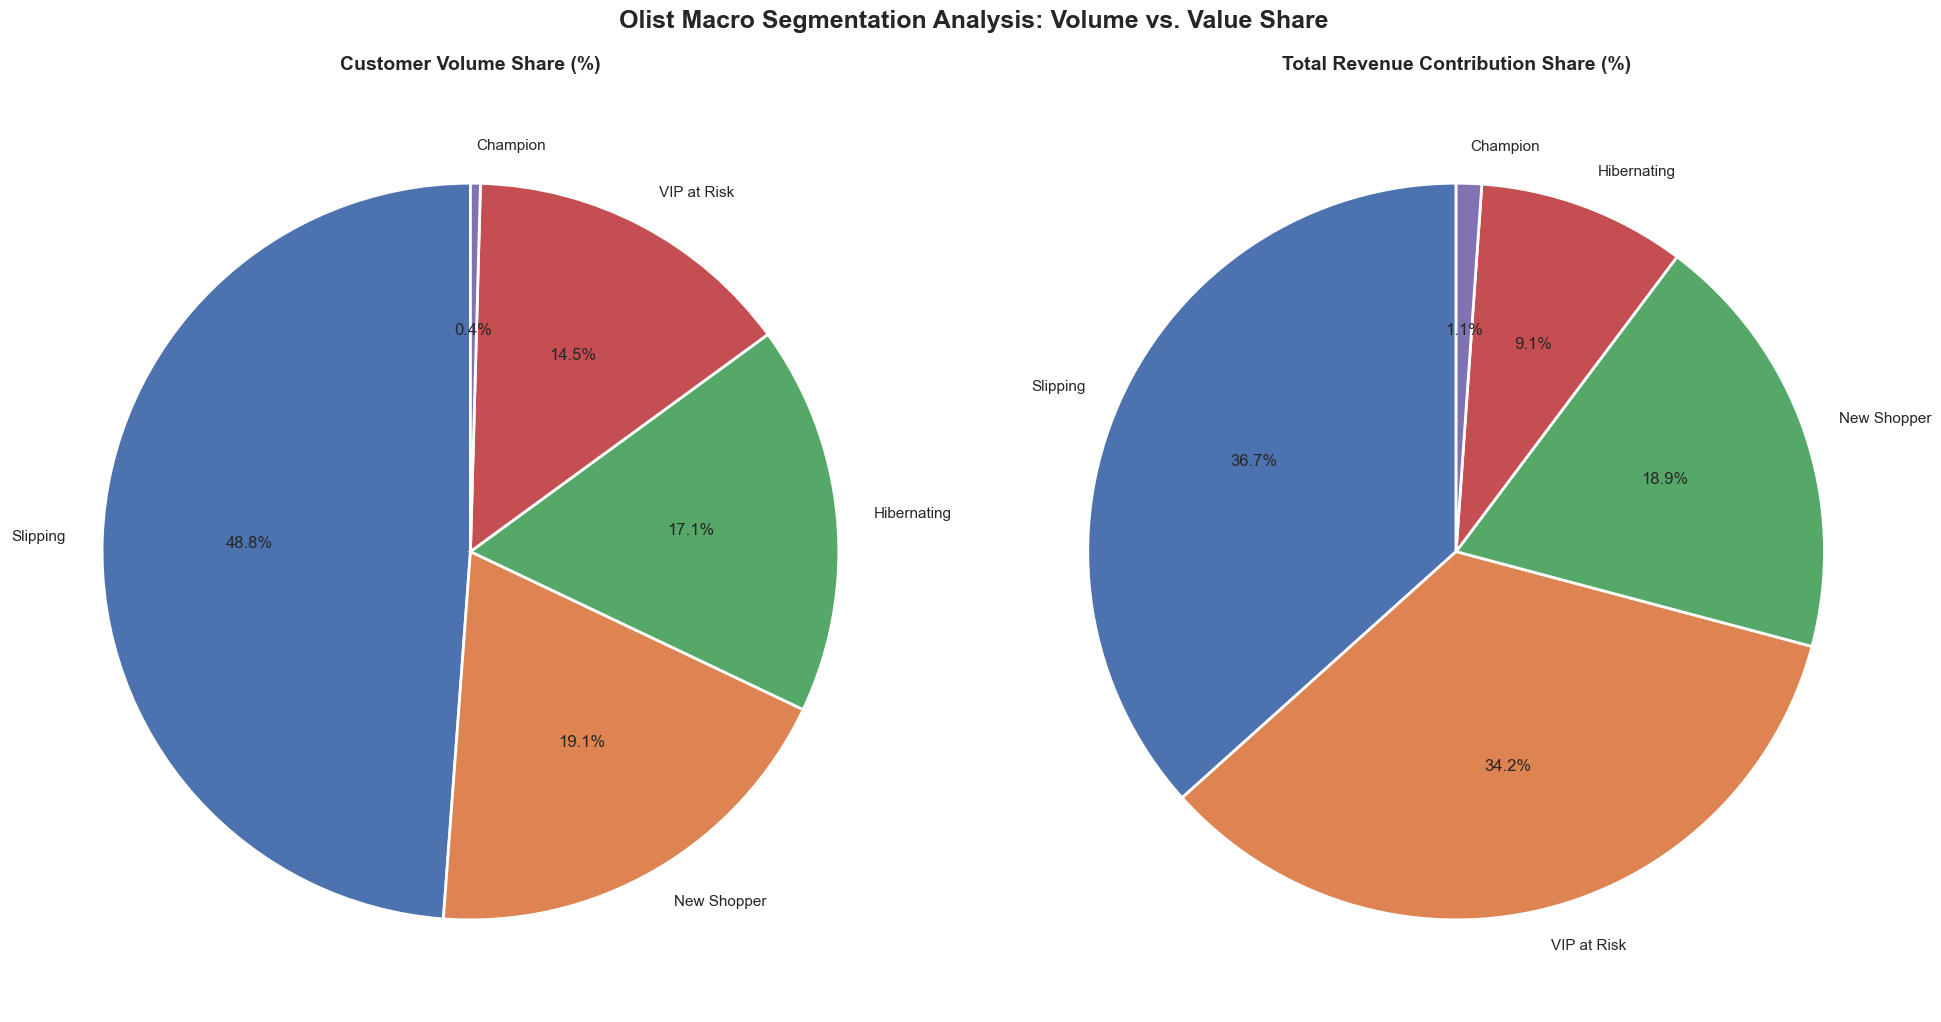

In [22]:
revenue_shares=total_revenue_report['revenue_contribution'].tolist()
volume_shares=segment_counts['Percentage'].tolist()
label_revenue=total_revenue_report['Customer_segment'].tolist()
label_volume=segment_counts['Customer_segment'].tolist()
fig,ax = plt.subplots(1,2,figsize=(20,10))
ax[0].pie(
    x=volume_shares, 
    labels=label_volume, 
    autopct='%1.1f%%', 
    startangle=90, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax[1].pie(
    x=revenue_shares, 
    labels=label_revenue,  
    autopct='%1.1f%%', 
    startangle=90, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax[0].set_title('Customer Volume Share (%)', fontsize=14, fontweight='bold', pad=15)
ax[1].set_title('Total Revenue Contribution Share (%)', fontsize=14, fontweight='bold', pad=15)
fig.suptitle('Olist Macro Segmentation Analysis: Volume vs. Value Share', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/olist_segmentation_pie_comparison.png',dpi=300,bbox_inches='tight')
plt.show()

## Executive Summary & Data-Driven Strategic Recommendations

Through this RFM analysis, we have successfully decoded Olist's customer base by cross-referencing **Recency** (how recently they bought), **Frequency** (how many times they bought), and **Monetary Value** (how much they spent). 

Rather than just presenting passive data, this framework delivers a complete **Algorithmic Marketing Next-Best-Action (NBA) Strategy** to convert these analytical insights into direct corporate revenue:

| Segment | Data Signal | Business Reality | Automated Next-Best-Action Strategy |
| :--- | :--- | :--- | :--- |
| **Champions** | Low recency, high frequency, and high monetary value scores. | Our most loyal, high-value brand advocates who love the platform. | **Reward & Amplify:** Do not waste discount margins here. Instead, offer early access to new product launches, exclusive loyalty points, or referral rewards to turn them into organic promoters. |
| **New Shopper** | Purchased once, very recently, with low overall monetary value. | Fresh leads who haven't built a consistent platform habit yet. | **Nurture Sequence:** Trigger an automated onboarding email sequence showcasing top-selling categories and offering a discount on their *second* order if placed within 14 days. |
| **VIP at Risk** | Frequent, high-spending buyers whose recency score is starting to drop. | They are actively losing interest or exploring competitor platforms. | **Exclusivity Campaign:** Re-engage them via high-touch customer service channels, feedback surveys, or premium personalized offers to rebuild their buying habit. |
| **Slipping** | High Monetary value historically, but hasn't purchased in a long time. | Our biggest past cash cows are actively leaving the platform. | **High Priority Win-Back:** Trigger a high-impact automated push notification or email campaign offering a heavy 20% discount or a direct free shipping voucher. |
| **Hibernating** | High recency (haven't bought in ages), low frequency, low monetary value. | Low-value, inactive users who are close to completely churning. | **Low-Cost Automation:** Do not spend heavy marketing budget here. Rely purely on low-cost automated email newsletters or standard seasonal sales re-engagement. |

---
**Python Analytics Phase: COMPLETE** *Next Phase: Exporting data matrix layers to Power BI to engineer an interactive, executive-facing performance dashboard.*